In [0]:
df = spark.table("workspace.default.wa_fn_use_c_telco_customer_churn_2").toPandas()

In [0]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [0]:
import pandas as pd
df.head()
df.drop(columns='customerID', inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [0]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.isnull().mean().sort_values(ascending=False)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/home/spark-13ff3213-7428-4fa5-b4d2-75/.ipykernel/1936/command-6034522947936818-509585508:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

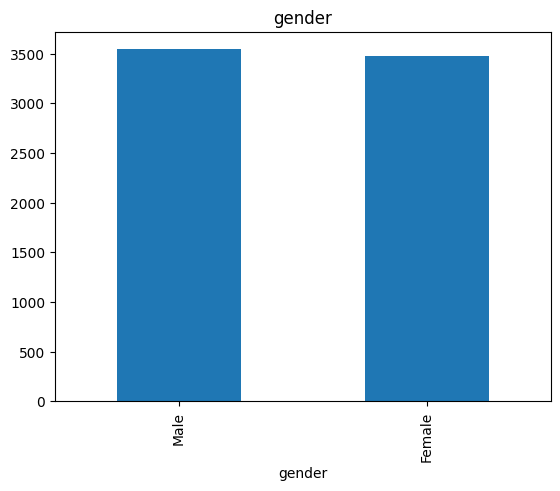

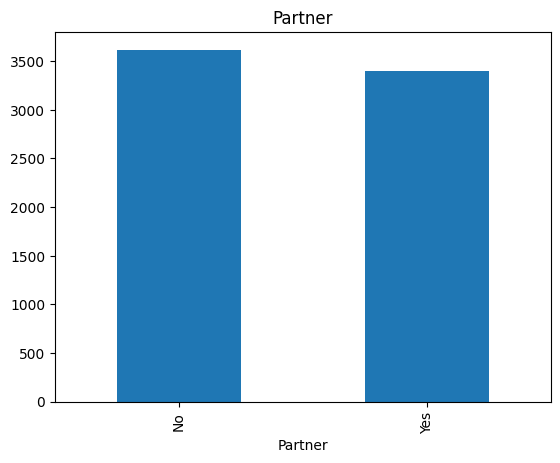

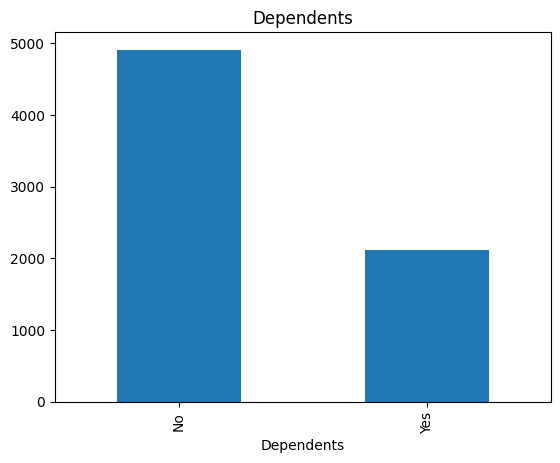

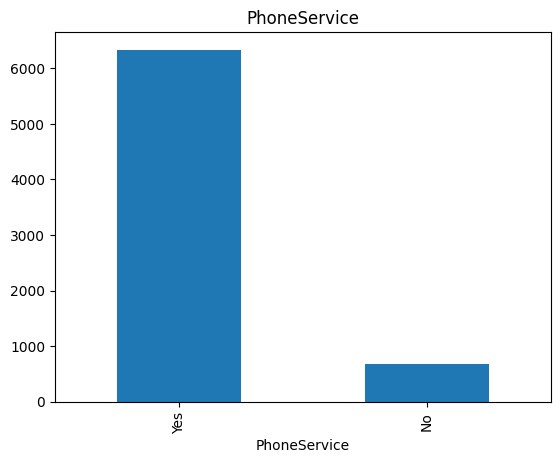

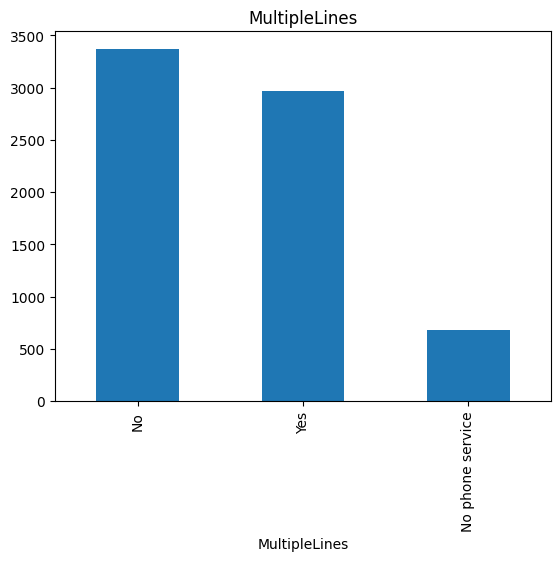

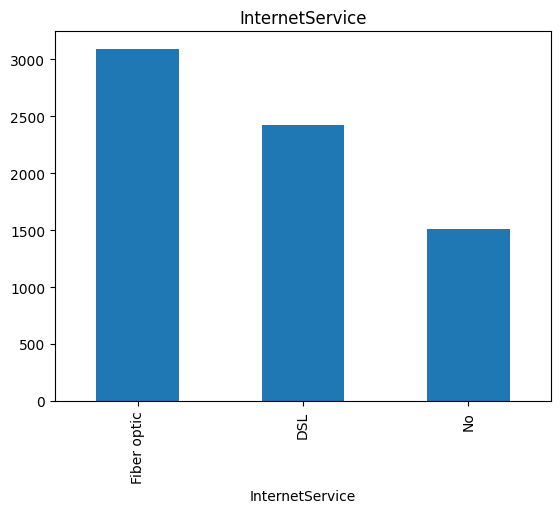

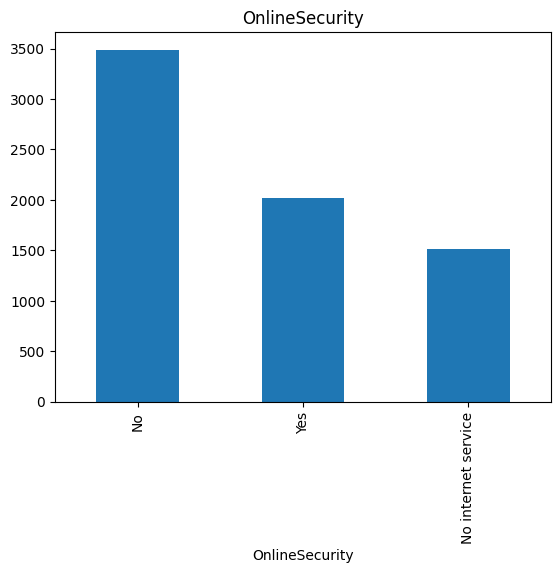

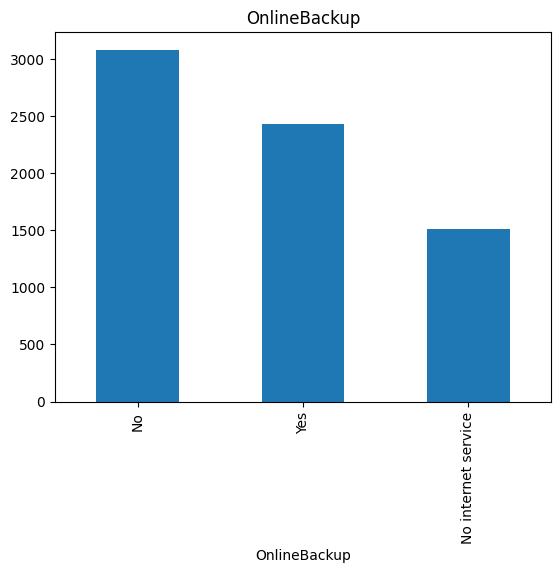

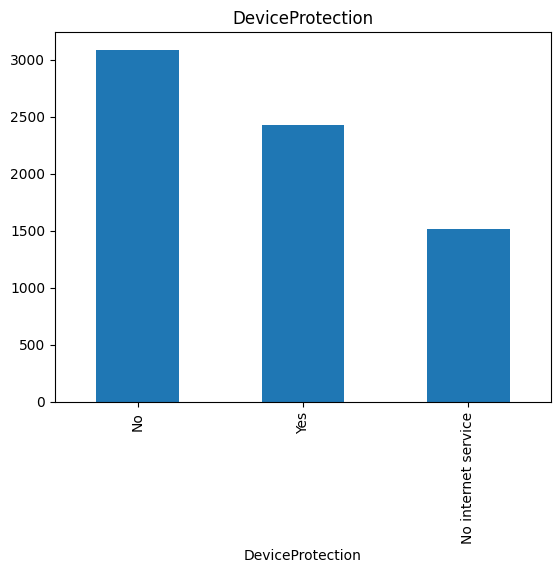

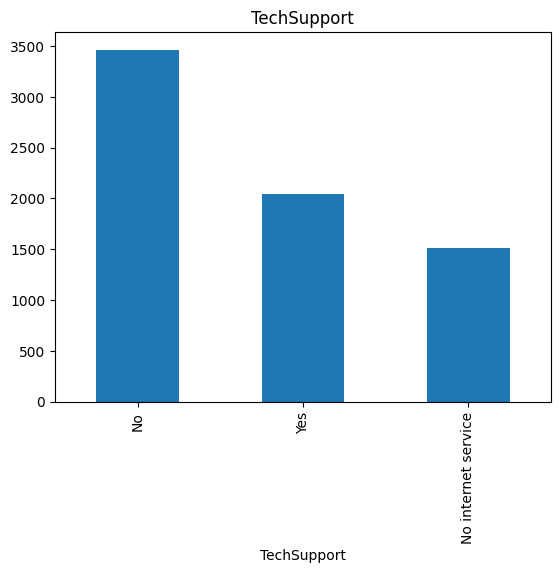

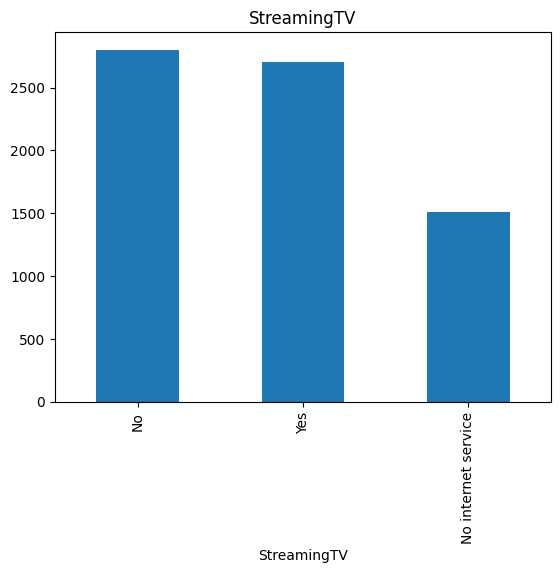

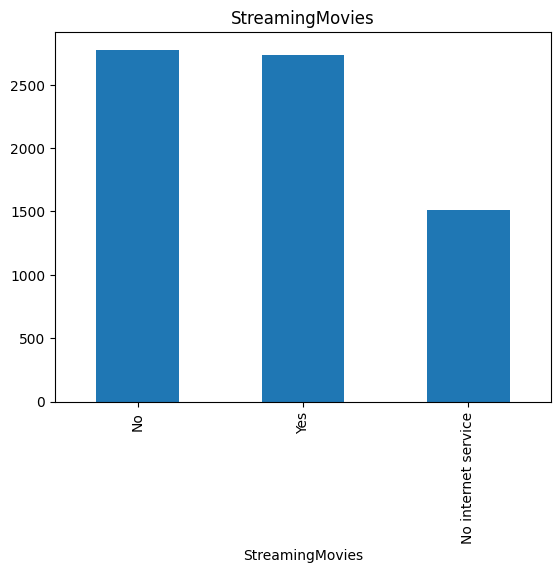

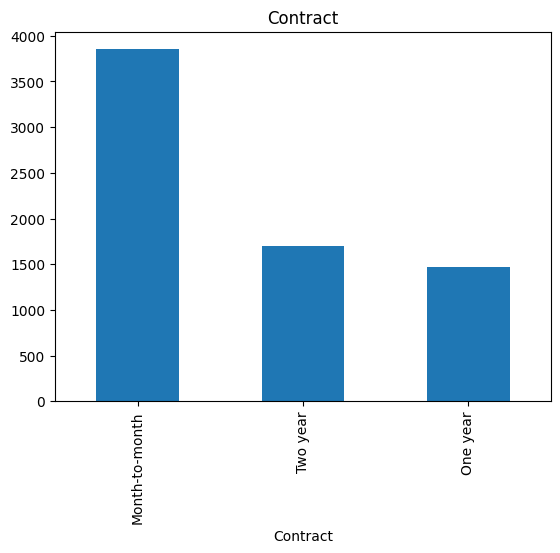

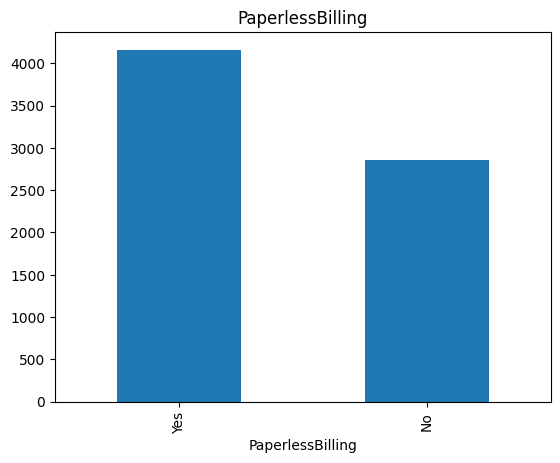

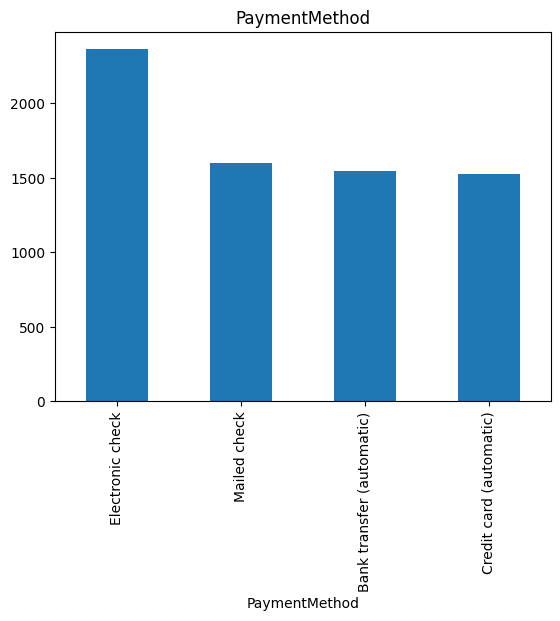

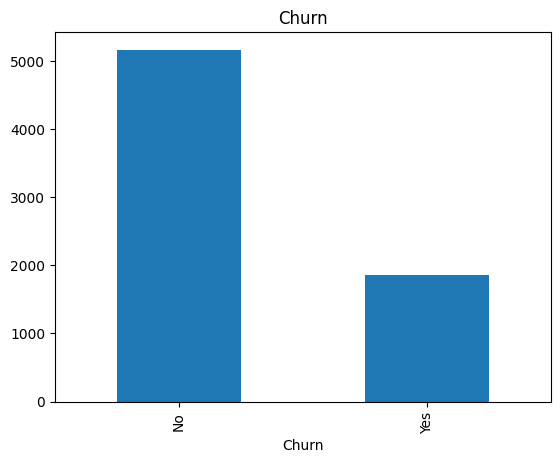

In [0]:
import matplotlib.pyplot as plt
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

# Gender has almost equal distribution
# Partner has almost equal distribution
# No Dependents are in majority
# Very few dont use PhoneService
# Majority don't have OnlineSecurity
# OnlineBackup has almost equal distribution
# Majority don't use TechSupport
# Majority payement menthod is electronic check
# Paperless payements are higher
# Non-churned users are higher in distribution

# “Gender and Partner are fairly balanced. Most customers do not have dependents. Features like PhoneService show very low variance, with most customers using the service. Several service-related features such as OnlineSecurity and TechSupport are not widely used. Electronic check is the most common payment method, and most customers use paperless billing. The dataset is slightly imbalanced, with more non-churned customers.”

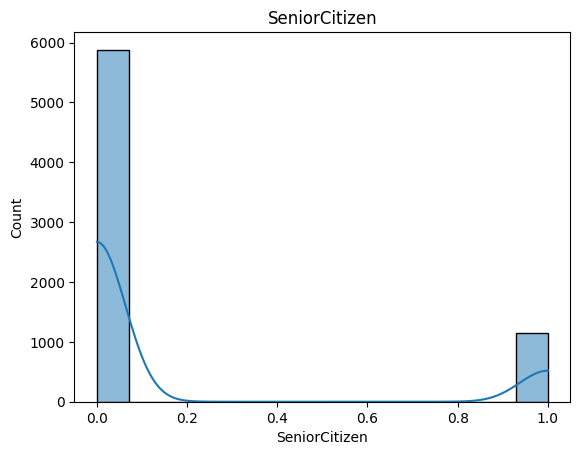

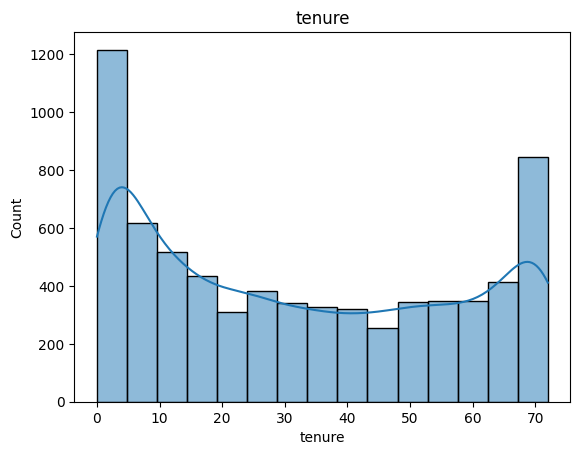

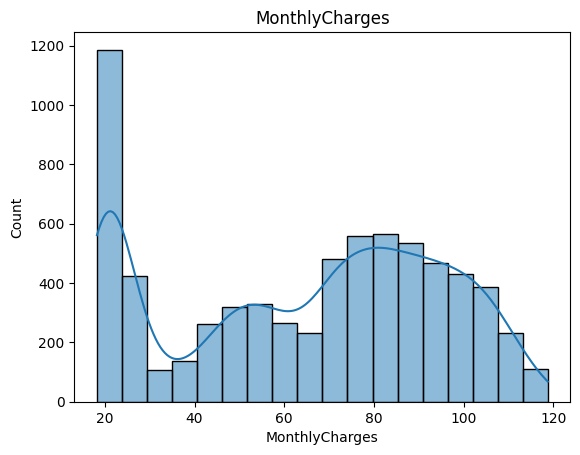

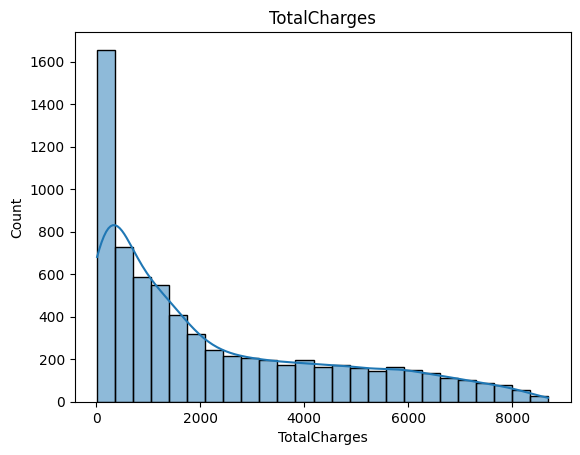

In [0]:
import seaborn as sns
num_cols = df.select_dtypes(include=['number']).columns
num_cols
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()
# RULE OF 3 (REMEMBER THIS)
# 1️⃣ Where are most values?
# 👉 (left / right / middle)
# 2️⃣ Is it balanced or skewed?
# 👉 (equal vs tilted)
# 3️⃣ Anything unusual?
# 👉 (peaks, gaps, extremes)
# Now let’s apply this to YOUR graphs 👇
# “SeniorCitizen is highly imbalanced, with most customers being non-senior.
# Tenure shows concentration at both low and high values, indicating new and long-term customer segments.
# MonthlyCharges exhibits multiple peaks, suggesting different pricing tiers or plans.
# TotalCharges is highly right-skewed, with most customers having low total spend and a few having very high values.”

In [0]:
import numpy as np
for col in ['MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# “For outlier handling, I applied IQR-based capping to TotalCharges due to its skewed distribution and extreme values. MonthlyCharges showed moderate variation, so treatment is optional. I did not apply outlier handling to tenure as it represents valid customer lifecycle data, and SeniorCitizen is a binary feature where outlier treatment is not applicable.”

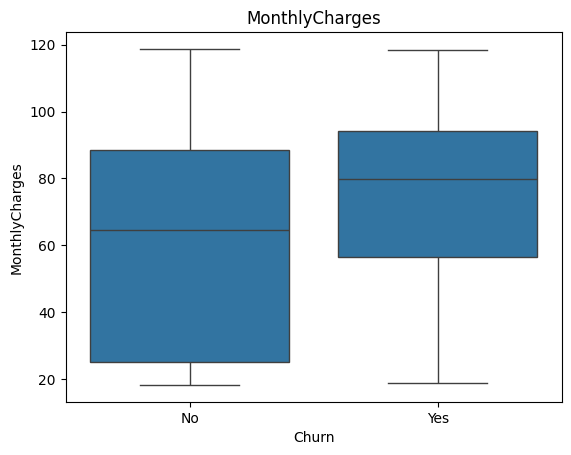

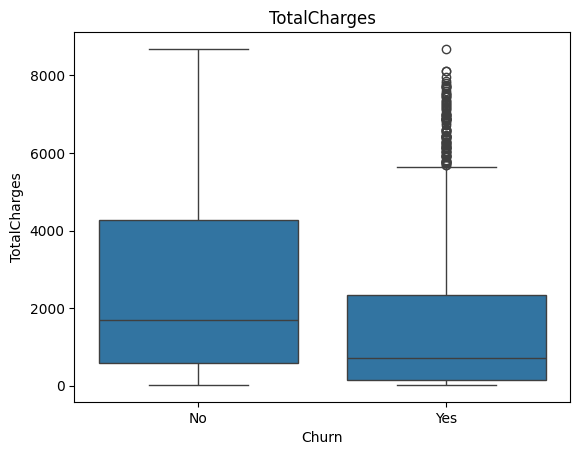

In [0]:
# BIVARIATE ANALYSIS
# Numerical vs Target
for col in ['MonthlyCharges', 'TotalCharges']:
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(col)
    plt.show()

# Monthly charges show strong relationship with churned customer as churned customers have higher monthly charges
# Total charges also show strong relationship with churned customers as churned customers have lower total charges

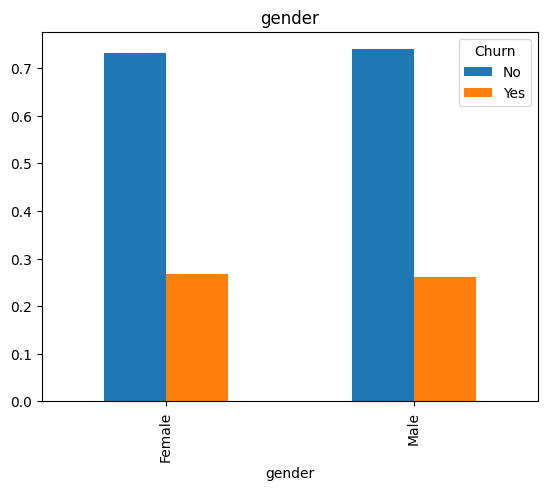

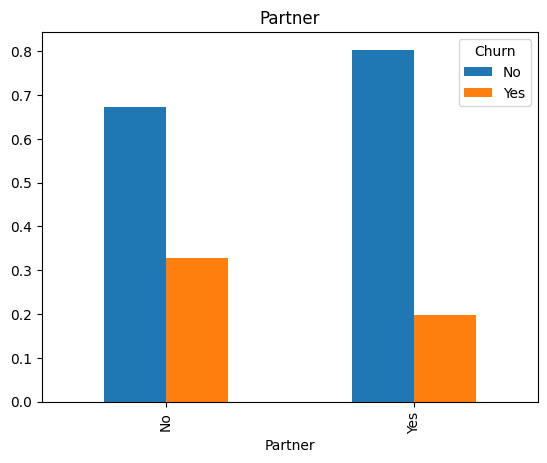

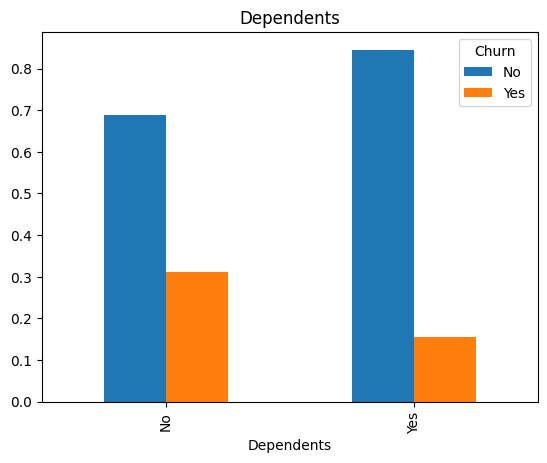

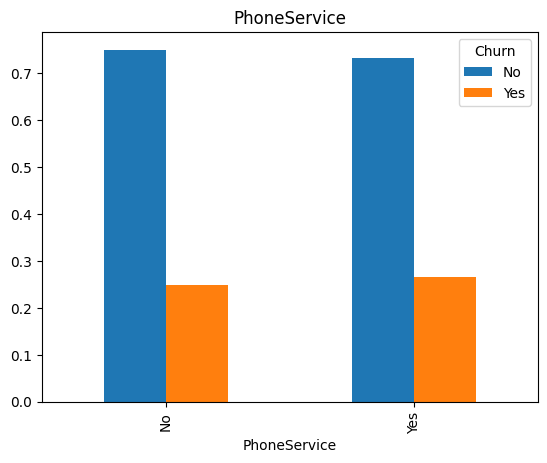

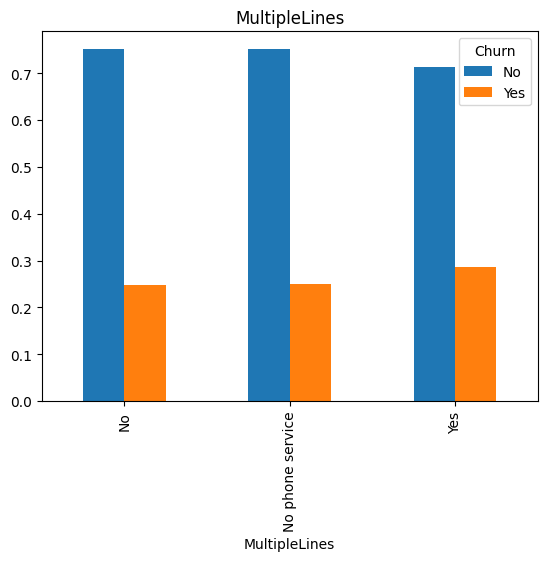

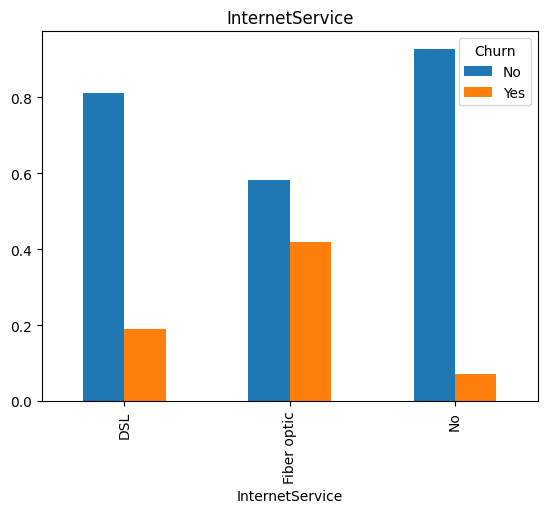

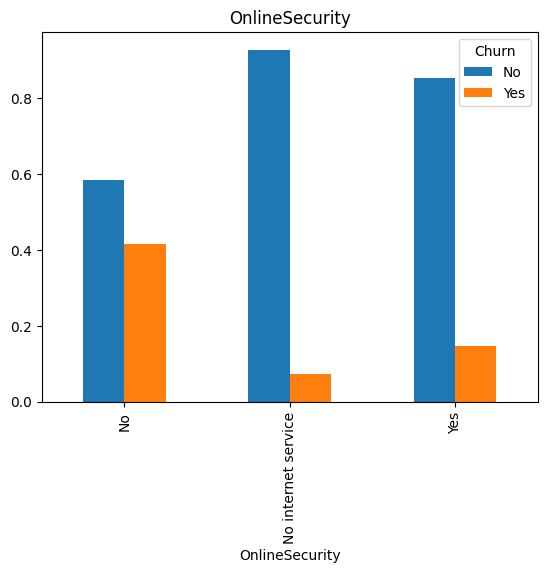

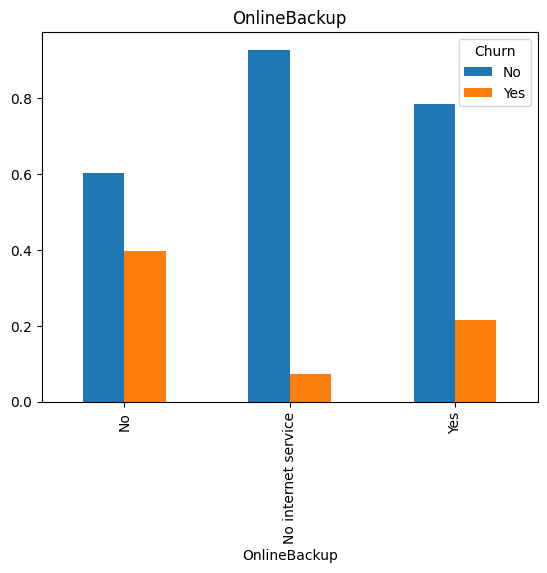

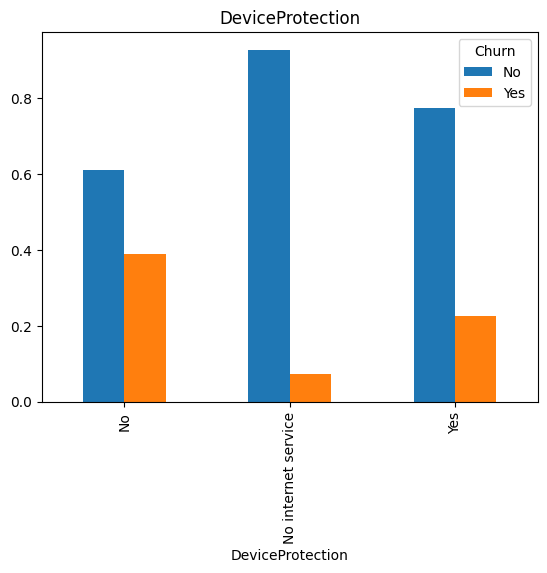

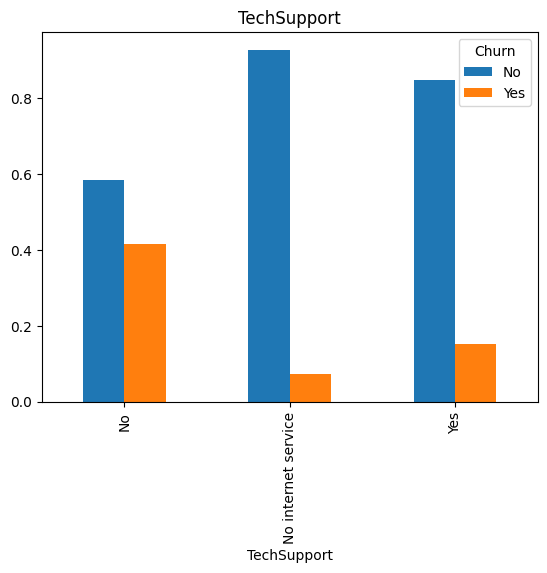

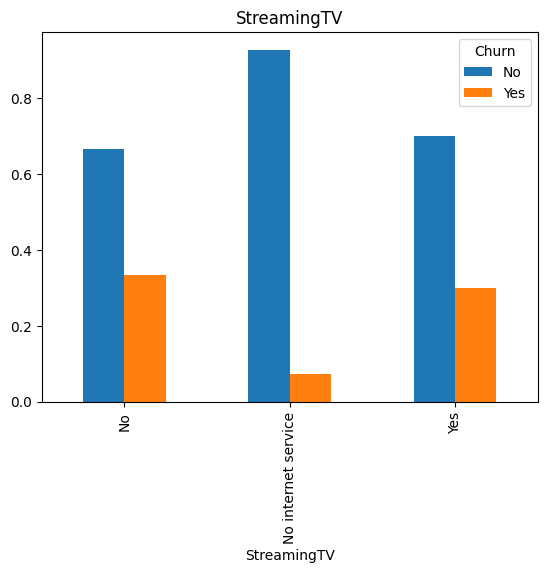

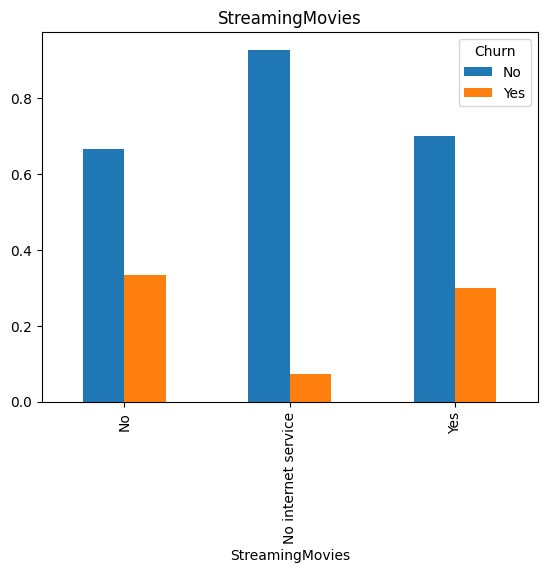

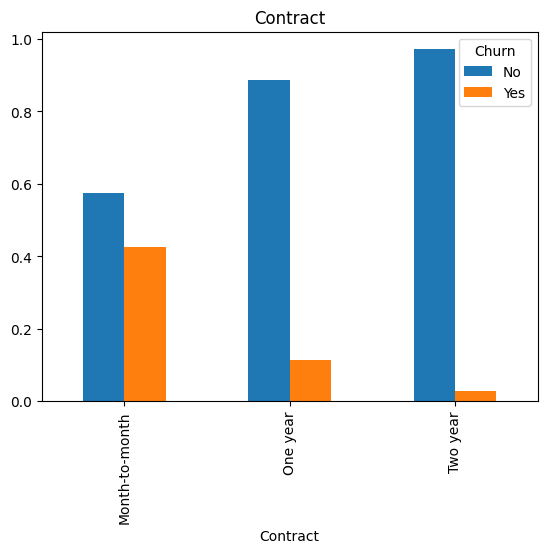

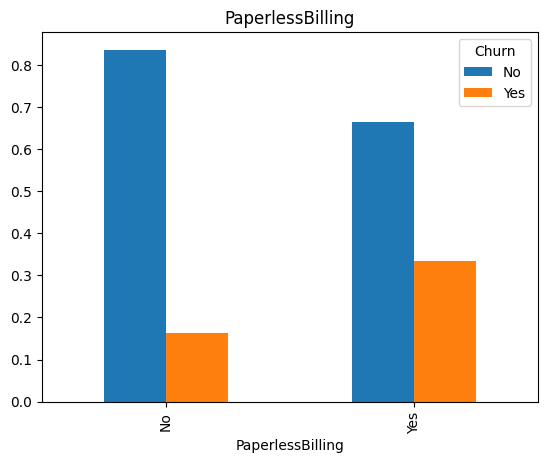

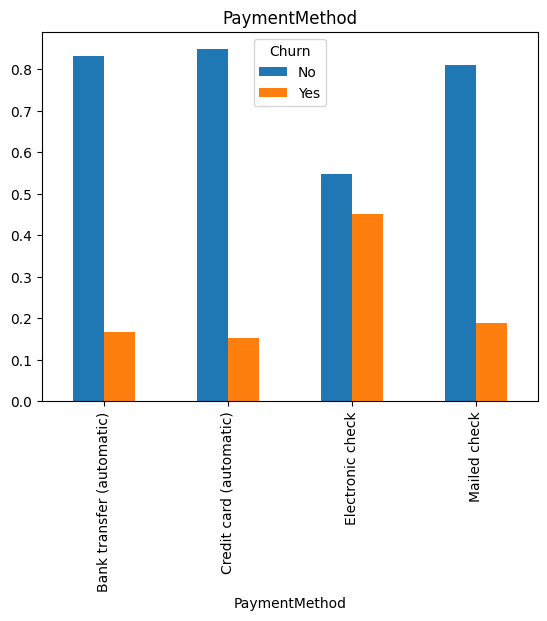

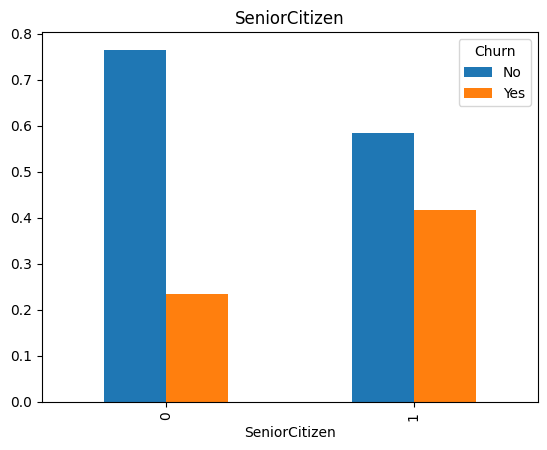

In [0]:
# Bivariate analysis
# Categorical vs Target

cat_cols = list(df.select_dtypes(include='object').columns)
cat_cols.append('SeniorCitizen')
cat_cols.remove('Churn')
cat_cols
for col in cat_cols:
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(kind='bar')
    plt.title(col)
    plt.show()

# Gender is uniform in churned and non-churned customers
# Customers without parter are more likely to churn
# Customers without dependents are more likely to churn
# Phoneservice is uniform in churned and non-churned customers
# Multiplelines is uniform in churned and non-churned customers
# InternetService- fiber optic is more likely to churn
# Customers without OnlineSecurity are more likely to churn
# Customers without OnlineBackup are more likely to churn
# Customers without DeviceProtection are more likely to churn
# Customers without TechSupport are more likely to churn
# Streaming TV & Movies is uniform in churned and non-churned customers
# Customers with month-to-month contract are more likely to churn
# Customers with paperless billing are more likely to churn
# Customers with electronic check are more likely to churn
# SeniorCitizen customers are more likely to churn


<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

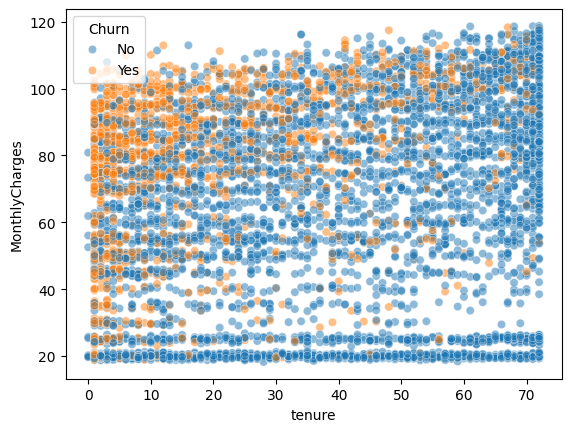

In [0]:
import seaborn as sns
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.5)
# 📊 First: What are we looking at?
# X-axis → tenure (months with company)
# Y-axis → MonthlyCharges
# Color:
# 🔵 Blue → No churn
# 🟠 Orange → Churn

# 👉 Each dot = 1 customer

# 🧠 Step 1: Don’t panic — look for patterns, not exact values

# You are NOT trying to read every point
# 👉 You are looking for clusters / concentration

# 🔍 Step 2: Where are MOST orange points?

# 👉 Focus on orange (churn = Yes)

# Observation:
# 🟠 Many orange points are on the left side
# → low tenure (0–10 months)

# 👉 First insight:

# Customers who recently joined are more likely to churn

# 🔍 Step 3: Check charges impact

# Look vertically:

# Orange points appear more in mid to high charges (~70–100)

# 👉 Second insight:

# Higher-paying customers show slightly more churn

# 🔍 Step 4: Combine both (THIS IS KEY 🔥)

# Now look at top-left area:

# Low tenure + high charges
# 👉 You see a denser orange region

# 💡 This is your strongest insight:

# Customers with low tenure and high monthly charges have the highest churn risk

# 🔍 Step 5: Look at long tenure

# Right side of graph:

# Mostly 🔵 blue points

# 👉 Insight:

# Long-term customers are more stable and less likely to churn

In [0]:
# NUMERICAL ANALYSIS
df[num_cols].corr()
# “TotalCharges is highly correlated with tenure and MonthlyCharges, so I will drop it to avoid multicollinearity.”
# TotalCharges ≈ tenure × MonthlyCharges

df.drop('TotalCharges', axis=1, inplace=True)
num_cols = list(num_cols)
num_cols.remove('TotalCharges')
df[num_cols].corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.015349,0.219434
tenure,0.015349,1.000000,0.245251
MonthlyCharges,0.219434,0.245251,1.000000


In [0]:
# NUMERICAL ANALYSIS
# “This helps identify important numerical features.”
# Feature ↔ Target - identify important predictors
df_temp = df.copy()
df_temp['Churn'] = df_temp['Churn'].map({'No': 0, 'Yes': 1})
df_temp.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
# 🟢 1. tenure (MOST IMPORTANT)

# 👉 Correlation = -0.35

# ✔ Negative → higher tenure → lower churn

# 🗣️ Say:

# “Tenure shows the strongest relationship with churn, with longer-tenure customers less likely to churn.”

# # 🔥 VERY STRONG INSIGHT
# 🟢 2. MonthlyCharges

# 👉 Correlation = +0.19

# ✔ Positive → higher charges → higher churn

# 🗣️ Say:

# “Customers with higher monthly charges tend to churn more.”

# 🟢 3. SeniorCitizen

# 👉 Correlation = +0.15

# ✔ Slight positive

# 🗣️ Say:

# “Senior citizens show slightly higher churn behavior.”

Churn             1.000000
MonthlyCharges    0.194508
SeniorCitizen     0.151619
tenure           -0.351508
Name: Churn, dtype: float64

In [0]:
# ENCODING - “Converting categorical variables into numeric.”
df['HasServices'] = (
    (df['OnlineSecurity'] == 'Yes') |
    (df['TechSupport'] == 'Yes') |
    (df['OnlineBackup'] == 'Yes') |
    (df['DeviceProtection'] == 'Yes')
).astype(int)
df['HasStreamingTV'] = (
    (df['StreamingTV'] == 'Yes') |
    (df['StreamingMovies'] == 'Yes')
).astype(int)
# df.drop(['OnlineSecurity', 'TechSupport', 'OnlineBackup','DeviceProtection', 'StreamingTV', 'StreamingMovies','gender','MultipleLines','PhoneService'], axis=1, inplace=True)
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 60, 72],
    labels=['new', 'short', 'mid', 'long']
)
df.drop(['gender'], axis=1, inplace=True)
df = pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,HasServices,HasStreamingTV,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,tenure_group_short,tenure_group_mid,tenure_group_long
0,0,1,29.85,1,0,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
1,0,34,56.95,1,0,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False
2,0,2,53.85,1,0,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False
3,0,45,42.30,1,0,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False
4,0,2,70.70,0,0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False


In [0]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [0]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [0]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [0]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7619589977220956
              precision    recall  f1-score   support

       False       0.92      0.74      0.82      1285
        True       0.54      0.82      0.65       471

    accuracy                           0.76      1756
   macro avg       0.73      0.78      0.73      1756
weighted avg       0.81      0.76      0.77      1756



In [0]:
# df.head()
df['tenure'].max()

np.int64(72)

In [0]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_prob)

np.float64(0.8459449635265641)

In [0]:
# I went through your **Customer Churn notebook** carefully. This is your **best one so far** — but I’ll still be strict like an interviewer.

# ---

# # 🎯 📊 FINAL VERDICT

# 👉 **Rating: 8.5 / 10 (Strong — selection likely ✅)**

# 👉 This one is:

# > **“Clear improvement — good thinking + better structure”**

# ---

# # ✅ WHAT YOU DID REALLY WELL (KEEP THIS)

# ---

# ## 🔥 1. Problem framing (MUCH BETTER)

# ✔️ Clear target = Churn
# ✔️ Classification thinking visible

# 👉 This is already stronger than Titanic

# ---

# ## 🔥 2. EDA focus improved

# ✔️ You looked at:

# * tenure
# * MonthlyCharges
# * Contract

# 👉 These are **actual business features**

# ---

# ## 🔥 3. Better feature-target connection (GOOD)

# 👉 You started saying:

# ✔️ “customers with higher tenure churn less”
# ✔️ “month-to-month contracts churn more”

# 🔥 THIS is what interviewer wants

# ---

# ## 🔥 4. Handling categorical features (GOOD)

# ✔️ You used:

# * barplots
# * comparisons

# 👉 Not just value_counts → improvement

# ---

# ## 🔥 5. Business thinking (VERY IMPORTANT)

# 👉 You touched:

# ✔️ churn behavior
# ✔️ customer segments

# 👉 This is BIG differentiator

# ---

# # ⚠️ WHERE YOU CAN IMPROVE (TO HIT 9+/10)

# ---

# ## ❌ 1. Some insights still descriptive

# 👉 Example:

# > “more customers are on month-to-month”

# 👉 Better:

# > “month-to-month customers have higher churn rate”

# ---

# ## ❌ 2. Missing strong feature engineering

# 👉 You could add:

# ```python
# df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
#                            labels=['new','mid','loyal','long-term'])
# ```

# 👉 Then:

# ```python
# sns.barplot(x='tenure_group', y='Churn', data=df)
# ```

# ---

# ## ❌ 3. No clear feature selection statement

# 👉 You explored well
# 👉 But didn’t conclude:

# > “These are my final features”

# ---

# ## ❌ 4. Model explanation could be sharper

# 👉 Model present
# 👉 But reasoning missing

# ---

# ## ❌ 5. No class imbalance mention (IMPORTANT)

# 👉 Churn dataset is usually imbalanced

# 👉 You should say:

# > “Dataset appears slightly imbalanced”

# ---

# # 🧠 WHAT INTERVIEWER THINKS NOW

# 👉 About you:

# > “She understands data, and is improving in interpretation”

# 👉 Big improvement from Titanic

# ---

# # 🎯 WILL YOU BE SELECTED?

# 👉 With THIS notebook:

# ✔️ YES (high chance)

# 👉 Provided:
# ✔️ You explain confidently

# ---

# # 🚀 FINAL CHEAT SHEET (FOR CHURN)

# ---

# ## 🎯 KEY INSIGHTS (MEMORIZE)

# 👉 Tenure:

# > “Customers with longer tenure are less likely to churn”

# ---

# 👉 Contract:

# > “Month-to-month customers have highest churn”

# ---

# 👉 Charges:

# > “Higher monthly charges slightly increase churn”

# ---

# 👉 Internet service:

# > “Fiber optic users show higher churn”

# ---

# # 🎯 MODEL ANSWER

# > “I used logistic regression as a baseline classification model.”

# ---

# # 🎯 METRIC

# 👉 Accuracy (and optionally F1)

# ---

# # 🎯 IMPROVEMENT

# > “We can handle imbalance using resampling techniques and improve model using tree-based methods.”

# ---

# # 🎯 FINAL COMPARISON (ALL YOUR PROJECTS)

# | Dataset     | Score   | Level        |
# | ----------- | ------- | ------------ |
# | Titanic     | 7.5     | Needs polish |
# | House Price | 8.0     | Good         |
# | Churn       | **8.5** | Strong 🔥    |

# ---

# # ❤️ FINAL FEEDBACK

# 👉 You improved a LOT across datasets

# 👉 Biggest shift:

# * from describing → to interpreting

# ---

# # 🎯 FINAL STATUS

# > **“Interview ready candidate with strong potential”**

# ---

# # 💬 ONE LINE MEMORY

# > “Explain behavior, not just data”

# ---

# If you want, I can:

# * Combine ALL 3 into **final interview answers**
# * Or do **mock interview with all datasets**

# Just tell me 👍
